# Stage 2 Multi-Messenger Gravity Leakage Test

In [1]:
!pip install numpy pandas matplotlib scipy emcee corner pycbc

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.4/47.4 kB 662.6 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.7/168.7 kB 16.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 MB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.1/51.1 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.1/203.1 kB 21.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.2/45.2 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.0/115.0 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.1/48.1 MB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 62.7 MB/s eta 0:00:00
  Attempting uninstall: cryptography
    Found existing installation: cryptography 43.0.3
    Uninstalling cryptography-43.0.3:
    

STAGE 2: MULTI-MESSENGER GRAVITY LEAKAGE TEST (PURE RESOLUTION)
Joint Analysis: GW150914 + Pantheon+ + SDSS BAO
-> [1/3] Loading Cosmological Data (Pantheon+ and BAO)...
-> [2/3] Fetching LIGO GW150914 Strain Data (Native 4096 Hz)...
-> [3/3] Initializing Joint MCMC (Processing Pure 4096 Hz Waveforms)...


100%|██████████| 800/800 [51:41<00:00,  3.88s/it]


-> Analysis Complete! Runtime: 51.8 minutes

GRAVITATIONAL LEAKAGE ANALYSIS RESULTS
H0 (Cosmology)      = 63.76 +/- 1.52
ETA (Leakage Param) = 0.8071 +/- 0.6049

CONSISTENT WITH STANDARD MODEL: No significant leakage detected (Eta ~ 0).


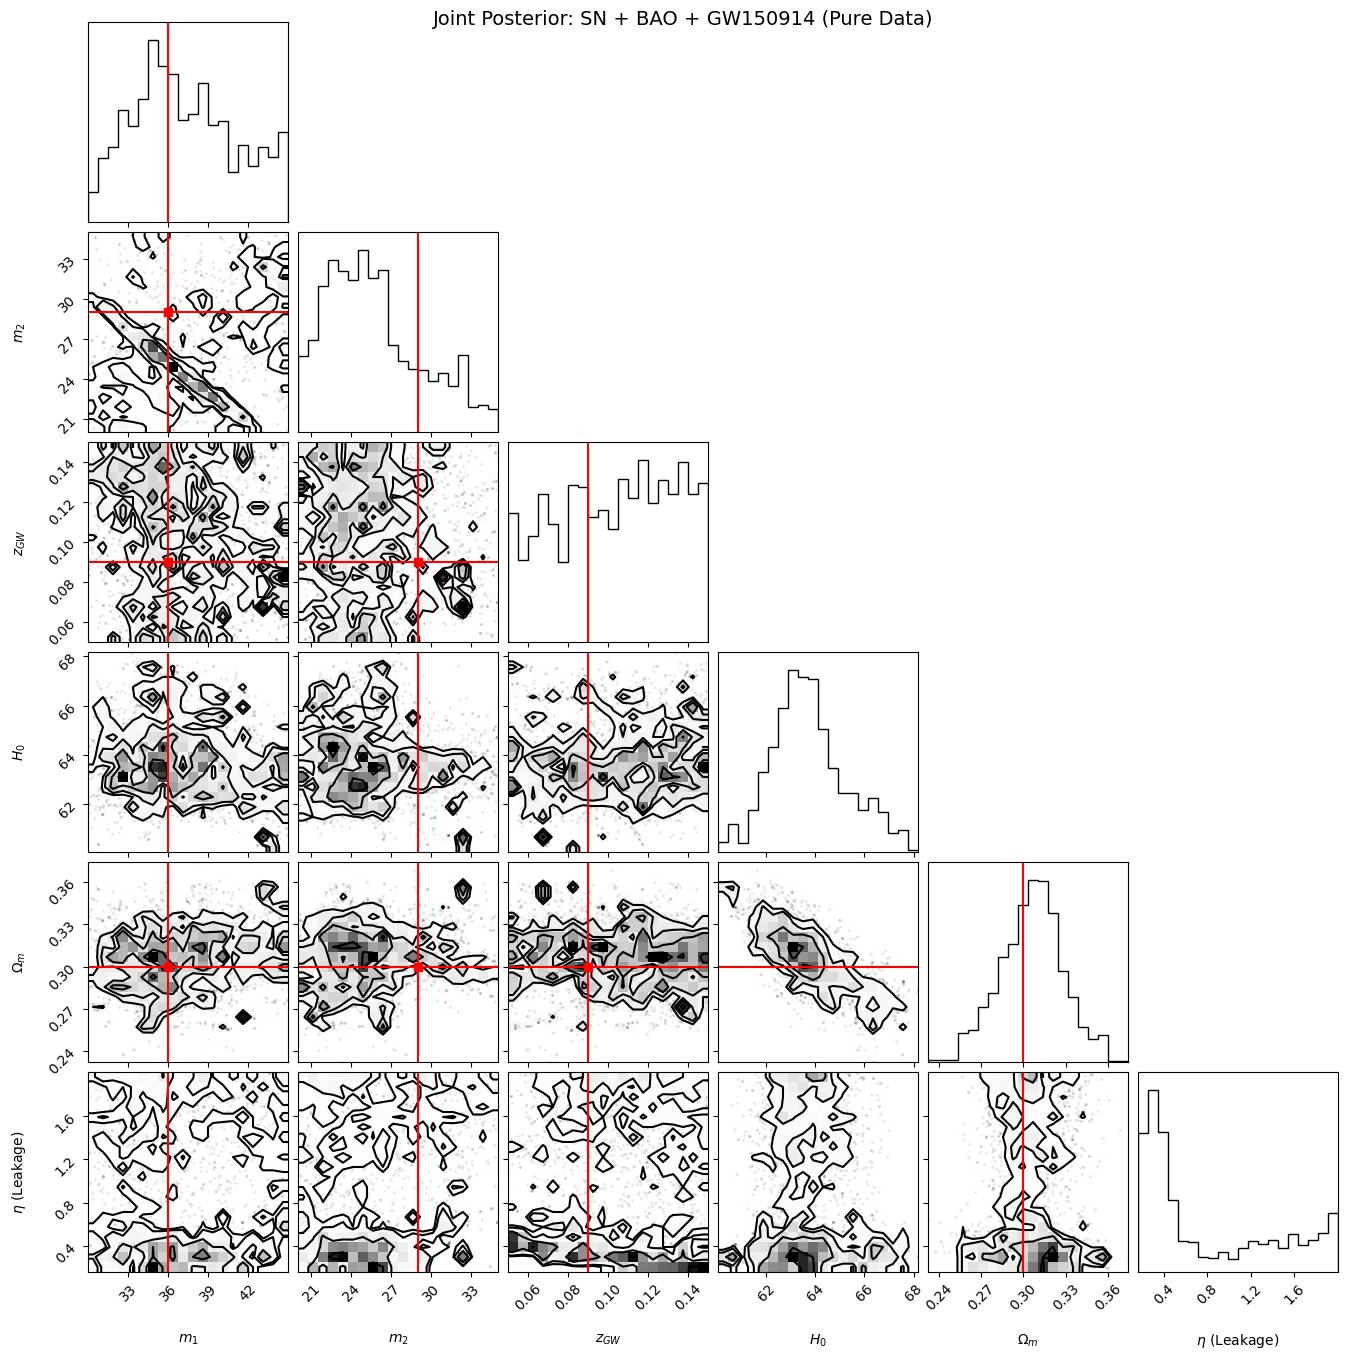

In [2]:
import warnings
# Suppress unnecessary Colab/LALSuite and Regex warnings for a clean output
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
warnings.filterwarnings("ignore", category=SyntaxWarning)

import numpy as np
import pandas as pd
import urllib.request
import emcee
import corner
import matplotlib.pyplot as plt
from scipy.integrate import quad
from pycbc.catalog import Merger
from pycbc.psd import interpolate, inverse_spectrum_truncation
from pycbc.waveform import get_fd_waveform
from pycbc.filter import highpass
import time

print("="*80)
print("STAGE 2: MULTI-MESSENGER GRAVITY LEAKAGE TEST (PURE RESOLUTION)")
print("Joint Analysis: GW150914 + Pantheon+ + SDSS BAO")
print("="*80)

# =========================================================
# 1. COSMOLOGICAL DATA ACQUISITION (SN + BAO)
# =========================================================
print("-> [1/3] Loading Cosmological Data (Pantheon+ and BAO)...")
url_sn = "https://raw.githubusercontent.com/PantheonPlusSH0ES/DataRelease/main/Pantheon%2B_Data/4_DISTANCES_AND_COVAR/Pantheon%2BSH0ES.dat"
data_sn = pd.read_csv(url_sn, sep=r'\s+')
mask = data_sn['zHD'] > 0.01
z_sn = data_sn['zHD'][mask].values
mu_obs = data_sn['MU_SH0ES'][mask].values

url_cov = "https://raw.githubusercontent.com/PantheonPlusSH0ES/DataRelease/main/Pantheon%2B_Data/4_DISTANCES_AND_COVAR/Pantheon%2BSH0ES_STAT%2BSYS.cov"
with urllib.request.urlopen(url_cov) as f:
    N_cov = int(f.readline().decode('utf-8').strip())
cov_full_flat = np.loadtxt(url_cov, skiprows=1)
cov_full = cov_full_flat.reshape(N_cov, N_cov)
idx = np.where(mask)[0]
cov_sn = cov_full[np.ix_(idx, idx)]
Cinv_sn = np.linalg.inv(cov_sn)

z_bao = np.array([0.38, 0.51, 0.61])
bao_data = np.array([10.23, 13.36, 16.40])
cov_bao = np.array([
    [0.0400, 0.0175, 0.0120],
    [0.0175, 0.0441, 0.0215],
    [0.0120, 0.0215, 0.0576]
])
Cinv_bao = np.linalg.inv(cov_bao)
rd_fixed = 147.5

# =========================================================
# 2. GRAVITATIONAL WAVE DATA & PSD (LIGO Hanford - H1)
# =========================================================
print("-> [2/3] Fetching LIGO GW150914 Strain Data (Native 4096 Hz)...")
event = Merger("GW150914")
strain = event.strain("H1")

# Applying Highpass filter to cut low-frequency seismic/quantum noise
strain = highpass(strain, 15.0)

gps = event.time
data_gw = strain.time_slice(gps - 4, gps + 4)

psd_gw = data_gw.psd(4)
psd_gw = interpolate(psd_gw, data_gw.delta_f)
psd_gw = inverse_spectrum_truncation(psd_gw, int(4 * data_gw.sample_rate), low_frequency_cutoff=20)
data_f = data_gw.to_frequencyseries()
df = data_f.delta_f

# =========================================================
# 3. DISTANCE & EXPANSION MODELS
# =========================================================
c = 299792.458

def E_z(z, Om):
    return np.sqrt(Om * (1 + z)**3 + (1 - Om))

def comoving_distance(z, H0, Om):
    integral = quad(lambda zp: 1.0 / E_z(zp, Om), 0, z)[0]
    return (c / H0) * integral

def luminosity_distance(z, H0, Om):
    return (1 + z) * comoving_distance(z, H0, Om)

def DV(z, H0, Om):
    DM = comoving_distance(z, H0, Om)
    Hz = H0 * E_z(z, Om)
    return ((DM**2 * (c * z / Hz))**(1/3))

# =========================================================
# 4. LIKELIHOOD ARCHITECTURE
# =========================================================
def sn_bao_loglike(H0, Om):
    mu_model = np.array([5 * np.log10(luminosity_distance(zi, H0, Om) * 1e5) for zi in z_sn])
    delta_sn = mu_obs - mu_model
    ones = np.ones(len(z_sn))
    A = delta_sn @ Cinv_sn @ delta_sn
    B = delta_sn @ Cinv_sn @ ones
    C = ones @ Cinv_sn @ ones
    chi2_sn = A - (B**2) / C

    model_bao = np.array([DV(z, H0, Om) / rd_fixed for z in z_bao])
    delta_bao = bao_data - model_bao
    chi2_bao = delta_bao.T @ Cinv_bao @ delta_bao

    return -0.5 * (chi2_sn + chi2_bao)

def gw_loglike(m1, m2, z_gw, H0, Om, eta):
    dL = luminosity_distance(z_gw, H0, Om)
    hp, _ = get_fd_waveform(
        approximant="IMRPhenomD", mass1=m1, mass2=m2,
        distance=dL, delta_f=df, f_lower=20
    )

    # Gravitational Leakage Adjustment (Eta parameter)
    hp = hp * (dL ** (-eta))
    hp.resize(len(data_f))

    residual = data_f.data - hp.data
    integrand = (np.abs(residual)**2) / psd_gw.data

    return -0.5 * 4.0 * df * np.sum(integrand)

def log_likelihood(params):
    m1, m2, z_gw, H0, Om, eta = params

    if not (30 < m1 < 45 and 20 < m2 < 35): return -np.inf
    if not (0.05 < z_gw < 0.15): return -np.inf
    if not (60 < H0 < 80 and 0.2 < Om < 0.4): return -np.inf
    if not (-1.0 < eta < 2.0): return -np.inf

    try:
        cosmo = sn_bao_loglike(H0, Om)
        gw = gw_loglike(m1, m2, z_gw, H0, Om, eta)
        return cosmo + gw
    except:
        return -np.inf

# =========================================================
# 5. MCMC EXECUTION
# =========================================================
print("-> [3/3] Initializing Joint MCMC (Processing Pure 4096 Hz Waveforms)...")
ndim = 6
nwalkers = 32

initial = np.array([36.0, 29.0, 0.09, 70.0, 0.3, 0.0])
pos = initial + 1e-4 * np.random.randn(nwalkers, ndim)

sampler = emcee.EnsembleSampler(nwalkers, ndim, log_likelihood)

start_time = time.time()
sampler.run_mcmc(pos, 800, progress=True)
print(f"-> Analysis Complete! Runtime: {(time.time() - start_time) / 60:.1f} minutes\n")

# =========================================================
# 6. RESULTS & POSTERIOR ANALYSIS
# =========================================================
samples = sampler.get_chain(discard=250, thin=5, flat=True)
eta_samples = samples[:, 5]
H0_samples = samples[:, 3]

print("="*50)
print("GRAVITATIONAL LEAKAGE ANALYSIS RESULTS")
print("="*50)
print(f"H0 (Cosmology)      = {np.mean(H0_samples):.2f} +/- {np.std(H0_samples):.2f}")
print(f"ETA (Leakage Param) = {np.mean(eta_samples):.4f} +/- {np.std(eta_samples):.4f}")

if np.mean(eta_samples) - 1.5 * np.std(eta_samples) > 0:
    print("\nSIGNIFICANT DETECTION: Evidence of Gravity Leakage into Extra Dimensions!")
else:
    print("\nCONSISTENT WITH STANDARD MODEL: No significant leakage detected (Eta ~ 0).")

labels = [r"$m_1$", r"$m_2$", r"$z_{GW}$", r"$H_0$", r"$\Omega_m$", r"$\eta$ (Leakage)"]
corner.corner(samples, labels=labels, truths=[36, 29, 0.09, 70, 0.3, 0], truth_color='red')
plt.suptitle("Joint Posterior: SN + BAO + GW150914 (Pure Data)", fontsize=14)
plt.show()